# 牛散跟单追踪工具

功能流程：
1. **更新牛散名单** — 从 tetegu.com 拉取最新名单，对比本地增量
2. **更新持仓记录** — 从东方财富增量拉取新增/增持记录
3. **计算跟单收益** — 仅对新增记录拉取行情计算（增量）
4. **生成排行报告** — 全量+近两年汇总，输出推荐
5. **跟单建议** — 推荐牛散最新持仓的跟单信号

数据存储在 `./niusan_db/` 目录下。

In [15]:
import sys, os, logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s', datefmt='%H:%M:%S')

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from niusan_tracker import (
    update_niusan_list,
    update_holdings,
    update_returns,
    generate_report,
    DB_DIR, DATA_FILES,
)
from niusan_tracker.ranking import get_follow_suggestions
import pandas as pd

pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 60)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:.2%}' if abs(x) < 10 else f'{x:.1f}')

print(f'数据目录: {DB_DIR}')
print('现有数据文件:')
for name, path in DATA_FILES.items():
    status = f'{path.stat().st_size/1024:.0f}KB' if path.exists() else '未创建'
    print(f'  {name}: {status}')

数据目录: /Users/Think/codes/big_money/etf_momentum/niusan_db
现有数据文件:
  niusan_list: 1KB
  holdings: 635KB
  returns: 2198KB
  summary_all: 16KB
  summary_2y: 15KB
  report: 15KB


## Step 1: 更新牛散名单

从 tetegu.com 获取最新排行，与本地名单对比。

In [24]:
result = update_niusan_list(top_n=100)

if result['new']:
    print(f"\n新增 {len(result['new'])} 位牛散:")
    for n in result['new']:
        print(f'  + {n}')
else:
    print('\n无新增牛散')

print(f"\n名单总计: {result['total']} 位")

14:45:46 [INFO] 从 tetegu 获取到 100 位牛散
14:45:46 [INFO] 牛散名单: 本地 100, 网页 100, 新增 0, 合计 100



无新增牛散

名单总计: 100 位


## Step 2: 更新持仓记录（增量）

对每位牛散，检查本地最新报告期，仅拉取更新的记录。

- 如果是首次运行、本地无数据，会全量拉取（约需 3-5 分钟）
- 后续增量更新通常只需 1-2 分钟

In [3]:
names = result['all']
holdings_result = update_holdings(names)

print(f"\n持仓记录: 总计 {holdings_result['total']} 条, 本次新增 {holdings_result['new_records']} 条")

11:23:28 [INFO]   关竹月: 33 条新进/增持
11:23:30 [INFO]   凌静芝: 10 条新进/增持
11:23:35 [INFO]   刘伟: 356 条新进/增持
11:23:37 [INFO]   刘峰: 103 条新进/增持
11:23:39 [INFO]   刘鑫: 59 条新进/增持
11:23:44 [INFO]   吕强: 521 条新进/增持
11:23:48 [INFO]   周信钢: 401 条新进/增持
11:23:53 [INFO]   周宇光: 358 条新进/增持
11:23:55 [INFO]   周宜霞: 32 条新进/增持
11:23:55 [INFO] 获取持仓进度: [10/100]
11:24:00 [INFO]   夏重阳: 411 条新进/增持
11:24:05 [INFO]   孙慧明: 263 条新进/增持
11:24:07 [INFO]   宁琛: 24 条新进/增持
11:24:10 [INFO]   宋文光: 77 条新进/增持
11:24:12 [INFO]   张东东: 69 条新进/增持
11:24:14 [INFO]   张伟: 214 条新进/增持
11:24:16 [INFO]   张勇: 245 条新进/增持
11:24:19 [INFO]   张秀: 366 条新进/增持
11:24:23 [INFO]   张素芬: 486 条新进/增持
11:24:26 [INFO]   张靖: 36 条新进/增持
11:24:26 [INFO] 获取持仓进度: [20/100]
11:24:28 [INFO]   徐国新: 162 条新进/增持
11:24:35 [INFO]   徐开东: 604 条新进/增持
11:24:37 [INFO]   戴文萍: 76 条新进/增持
11:24:40 [INFO]   方威: 106 条新进/增持
11:24:42 [INFO]   李伟: 270 条新进/增持
11:24:44 [INFO]   李平: 113 条新进/增持
11:24:49 [INFO]   李斌: 299 条新进/增持
11:24:56 [INFO]   李欣: 544 条新进/增持
11:24:58 [INFO]   李胜军: 192 条新进/增持
11:25


持仓记录: 总计 14270 条, 本次新增 7416 条


## Step 3: 计算跟单收益（增量）

仅对**尚未计算**的持仓记录拉取 baostock 行情并计算收益率。

- 已经算过的记录不会重复查询
- 新增记录约 200 条/分钟

In [4]:
returns_result = update_returns()

print(f"\n收益计算: 总计 {returns_result['total']} 条, 本次新算 {returns_result['new_calc']} 条")

11:28:07 [INFO] 持仓总计 14270 条, 已计算 8077 条, 需新算 7269 条
11:28:07 [INFO] 计算进度 [1/7269]


login success!


11:29:05 [INFO] 计算进度 [200/7269]
11:29:59 [INFO] 计算进度 [400/7269]
11:30:54 [INFO] 计算进度 [600/7269]
11:31:52 [INFO] 计算进度 [800/7269]
11:33:00 [INFO] 计算进度 [1000/7269]
11:34:12 [INFO] 计算进度 [1200/7269]
11:35:19 [INFO] 计算进度 [1400/7269]
11:36:29 [INFO] 计算进度 [1600/7269]
11:37:30 [INFO] 计算进度 [1800/7269]
11:38:37 [INFO] 计算进度 [2000/7269]
11:39:46 [INFO] 计算进度 [2200/7269]
11:41:05 [INFO] 计算进度 [2400/7269]
11:41:52 [INFO] 计算进度 [2600/7269]
11:42:51 [INFO] 计算进度 [2800/7269]
11:43:59 [INFO] 计算进度 [3000/7269]
11:44:57 [INFO] 计算进度 [3200/7269]
11:46:37 [INFO] 计算进度 [3400/7269]
11:47:34 [INFO] 计算进度 [3600/7269]
11:48:45 [INFO] 计算进度 [3800/7269]
11:49:44 [INFO] 计算进度 [4000/7269]
11:50:57 [INFO] 计算进度 [4200/7269]
11:52:05 [INFO] 计算进度 [4400/7269]
11:53:16 [INFO] 计算进度 [4600/7269]
11:54:58 [INFO] 计算进度 [4800/7269]
11:56:12 [INFO] 计算进度 [5000/7269]
11:57:28 [INFO] 计算进度 [5200/7269]
11:58:27 [INFO] 计算进度 [5400/7269]
11:59:48 [INFO] 计算进度 [5600/7269]
12:01:17 [INFO] 计算进度 [5800/7269]
12:02:37 [INFO] 计算进度 [6000/7269]
12:03:51 [INFO

logout success!


12:09:48 [INFO] 收益计算完成: 总计 14274 条, 本次新增 6197 条



收益计算: 总计 14274 条, 本次新算 6197 条


## Step 4: 生成排行报告

In [26]:
# 重新加载 ranking 模块，确保使用磁盘最新代码（报告中的牛散链接等）
import importlib
import niusan_tracker.ranking as _ranking
importlib.reload(_ranking)
report = _ranking.generate_report()

if not report:
    print('无数据生成报告')
else:
    print('=== 整体统计 ===')
    for k, v in report['stats'].items():
        print(f"{k}: {v}")

    print(f"\n=== 全量汇总 TOP 15 ===")
    display(report['summary_all'].head(15))

    print(f"\n=== 近两年汇总 TOP 15 ===")
    display(report['summary_2y'].head(15))

14:48:24 [INFO] 报告已生成: /Users/Think/codes/big_money/etf_momentum/niusan_db/analysis_report.md


=== 整体统计 ===
全量_1月: {'样本': 14270, '平均': '4.42%', '中位': '1.79%', '胜率': '56.0%'}
近2年_1月: {'样本': 3126, '平均': '6.52%', '中位': '3.54%', '胜率': '61.1%'}
全量_2月: {'样本': 14262, '平均': '4.37%', '中位': '1.16%', '胜率': '53.0%'}
近2年_2月: {'样本': 3119, '平均': '8.32%', '中位': '4.80%', '胜率': '60.7%'}
全量_3月: {'样本': 14242, '平均': '6.61%', '中位': '1.82%', '胜率': '53.6%'}
近2年_3月: {'样本': 3106, '平均': '15.01%', '中位': '9.15%', '胜率': '67.7%'}

=== 全量汇总 TOP 15 ===


,牛散,记录数,最早记录日期,最新记录日期,新进数,增持数,跟单1月_样本数,跟单1月_平均收益,跟单1月_中位收益,跟单1月_胜率,跟单1月_最大收益,跟单1月_最大回撤,跟单2月_样本数,跟单2月_平均收益,跟单2月_中位收益,跟单2月_胜率,跟单2月_最大收益,跟单2月_最大回撤,跟单3月_样本数,跟单3月_平均收益,跟单3月_中位收益,跟单3月_胜率,跟单3月_最大收益,跟单3月_最大回撤
0,凌静芝,8,2022-06-30,2025-11-14,6,2,8,20.31%,10.00%,62.50%,74.27%,-20.19%,8,24.35%,20.31%,75.00%,94.55%,-20.00%,7,35.35%,13.00%,85.71%,124.56%,-12.53%
1,关竹月,28,2006-03-31,2025-09-30,15,13,28,7.40%,1.78%,60.71%,56.83%,-17.96%,28,17.07%,2.58%,53.57%,160.06%,-21.78%,28,22.05%,12.10%,64.29%,148.60%,-14.49%
2,刘军,99,2003-12-31,2025-09-30,70,29,99,11.04%,3.62%,67.68%,233.33%,-24.95%,99,13.33%,2.10%,58.59%,340.73%,-36.23%,99,15.04%,2.56%,54.55%,453.42%,-30.25%
3,王冬梅,23,2012-12-31,2025-09-30,19,4,23,6.31%,0.83%,52.17%,54.84%,-16.94%,23,11.28%,2.87%,73.91%,121.59%,-21.27%,23,12.71%,5.37%,60.87%,86.14%,-29.37%
4,郑文宝,88,2011-12-31,2025-09-30,20,68,88,6.51%,3.68%,61.36%,96.43%,-31.34%,88,11.10%,7.68%,64.77%,137.83%,-34.80%,88,12.98%,5.94%,60.23%,106.85%,-37.09%
5,宁琛,20,2007-06-30,2025-09-30,8,12,20,9.70%,4.40%,60.00%,72.57%,-15.98%,20,10.57%,4.44%,75.00%,61.05%,-17.92%,20,15.16%,13.96%,85.00%,70.50%,-23.98%
6,戴文萍,73,2015-06-30,2025-10-09,63,10,73,2.30%,1.87%,57.53%,56.16%,-69.40%,73,9.22%,1.89%,56.16%,217.01%,-84.05%,72,10.95%,6.84%,65.28%,142.51%,-84.05%
7,周宇光,348,2003-12-31,2025-09-30,157,191,348,5.78%,4.39%,63.22%,114.15%,-25.16%,348,9.05%,4.14%,63.79%,420.25%,-26.73%,348,10.94%,5.84%,59.77%,371.17%,-34.65%
8,张跃军,93,2006-06-30,2025-11-10,39,54,93,4.57%,3.03%,60.22%,66.23%,-18.60%,93,8.96%,3.07%,63.44%,215.79%,-32.62%,90,11.18%,5.45%,63.33%,174.56%,-35.84%
9,何小春,82,2005-03-31,2025-09-30,33,49,82,5.40%,3.37%,63.41%,70.21%,-22.25%,82,8.23%,5.16%,57.32%,216.45%,-32.71%,82,15.22%,3.81%,59.76%,275.76%,-23.97%



=== 近两年汇总 TOP 15 ===


,牛散,记录数,最早记录日期,最新记录日期,新进数,增持数,跟单1月_样本数,跟单1月_平均收益,跟单1月_中位收益,跟单1月_胜率,跟单1月_最大收益,跟单1月_最大回撤,跟单2月_样本数,跟单2月_平均收益,跟单2月_中位收益,跟单2月_胜率,跟单2月_最大收益,跟单2月_最大回撤,跟单3月_样本数,跟单3月_平均收益,跟单3月_中位收益,跟单3月_胜率,跟单3月_最大收益,跟单3月_最大回撤
0,关竹月,9,2024-12-31,2025-09-30,7,2,9,20.37%,15.47%,88.89%,56.83%,-3.49%,9,44.37%,14.38%,66.67%,160.06%,-3.29%,9,45.96%,15.42%,88.89%,148.60%,-1.03%
1,王冬梅,4,2025-03-31,2025-09-30,2,2,4,9.21%,3.84%,50.00%,37.22%,-8.06%,4,40.87%,19.60%,100.00%,121.59%,2.69%,4,45.17%,34.37%,100.00%,86.14%,25.80%
2,凌静芝,6,2025-06-30,2025-11-14,5,1,6,28.62%,26.98%,66.67%,74.27%,-3.92%,6,30.08%,27.04%,83.33%,94.55%,-20.00%,5,45.47%,51.24%,80.00%,124.56%,-12.53%
3,张勇,33,2024-03-31,2025-09-30,12,21,33,21.71%,6.31%,63.64%,167.16%,-54.76%,33,29.10%,5.90%,63.64%,304.77%,-46.40%,33,39.85%,15.65%,66.67%,347.34%,-31.97%
4,刘军,18,2024-03-31,2025-09-30,17,1,18,6.52%,-0.04%,50.00%,60.68%,-24.95%,18,25.74%,6.54%,66.67%,340.73%,-27.55%,18,34.79%,4.33%,66.67%,453.42%,-25.85%
5,方威,14,2024-03-31,2025-09-30,8,6,14,4.59%,1.22%,50.00%,37.23%,-11.38%,14,22.82%,6.60%,57.14%,134.91%,-15.41%,14,19.28%,5.00%,71.43%,119.62%,-13.16%
6,宁琛,10,2024-03-31,2025-09-30,5,5,10,17.19%,8.85%,70.00%,72.57%,-15.98%,10,19.62%,12.82%,80.00%,61.05%,-0.76%,10,25.99%,24.10%,90.00%,70.50%,-16.03%
7,郑文宝,20,2024-03-31,2025-09-30,5,15,20,7.69%,6.04%,70.00%,40.21%,-10.83%,20,16.33%,12.17%,75.00%,52.75%,-26.86%,20,17.54%,18.27%,75.00%,50.47%,-11.27%
8,魏巍,92,2024-03-31,2025-09-30,51,41,92,12.04%,7.83%,67.39%,143.75%,-51.51%,89,15.97%,12.20%,70.79%,122.57%,-46.87%,89,21.30%,13.95%,70.79%,188.30%,-25.82%
9,周爽,38,2024-03-31,2025-09-30,16,22,38,14.67%,10.56%,71.05%,58.04%,-20.97%,38,14.72%,13.38%,71.05%,81.62%,-22.58%,38,17.91%,19.10%,73.68%,55.56%,-19.35%


## Step 5: 推荐牛散及跟单建议

In [17]:
recommended = report.get('recommended', pd.DataFrame())

if recommended.empty:
    print('暂无推荐')
else:
    show_cols = [
        '牛散', '记录数', '最早记录日期',
        '全量_跟单1月_胜率', '全量_跟单2月_胜率', '全量_跟单3月_胜率',
        '全量_跟单3月_平均收益',
        '近2年_记录数',
        '近2年_跟单1月_胜率', '近2年_跟单2月_胜率', '近2年_跟单3月_胜率',
        '近2年_跟单3月_平均收益',
        '综合评分',
    ]
    show_cols = [c for c in show_cols if c in recommended.columns]
    print(f'共 {len(recommended)} 位牛散通过筛选\n')
    display(recommended[show_cols])

共 52 位牛散通过筛选



,牛散,记录数,最早记录日期,全量_跟单1月_胜率,全量_跟单2月_胜率,全量_跟单3月_胜率,全量_跟单3月_平均收益,近2年_记录数,近2年_跟单1月_胜率,近2年_跟单2月_胜率,近2年_跟单3月_胜率,近2年_跟单3月_平均收益,综合评分
0,关竹月,28,2006-03-31,60.71%,53.57%,64.29%,22.05%,9,88.89%,66.67%,88.89%,45.96%,52.27%
1,宁琛,20,2007-06-30,60.00%,75.00%,85.00%,15.16%,10,70.00%,80.00%,90.00%,25.99%,47.59%
2,李胜军,170,2011-09-30,71.18%,67.06%,64.71%,14.36%,66,68.18%,60.61%,69.70%,31.08%,40.76%
3,林新,228,2006-12-31,63.16%,68.42%,70.04%,12.82%,71,70.42%,70.42%,81.43%,17.14%,39.85%
4,刘军,99,2003-12-31,67.68%,58.59%,54.55%,15.04%,18,50.00%,66.67%,66.67%,34.79%,39.80%
5,陈彩娅,62,2019-09-30,62.90%,59.68%,79.03%,10.12%,42,71.43%,64.29%,80.95%,13.46%,39.17%
6,陆丽红,56,2016-03-31,56.36%,56.36%,64.81%,7.70%,19,72.22%,77.78%,82.35%,19.06%,38.34%
7,徐国新,139,2006-06-30,58.27%,60.43%,60.43%,12.53%,80,60.00%,70.00%,75.00%,20.86%,37.83%
8,张涛,96,2003-12-31,60.42%,53.12%,61.46%,7.99%,23,52.17%,60.87%,82.61%,17.43%,37.50%
9,戴文萍,73,2015-06-30,57.53%,56.16%,65.28%,10.95%,36,69.44%,61.11%,80.00%,13.63%,37.17%


In [18]:
# 范围：本期报告期（按月份）+ 上次分析之后的新记录；推荐度：星级、持股变动、至今涨幅、综合推荐值
suggestions = get_follow_suggestions(top_n=10)

if suggestions.empty:
    print('暂无本期持仓跟单建议（可先运行 Step 1 更新名单以获取牛散详情链接）')
else:
    cols = ['星级', '牛散', '股票代码', '股票名称', '持股变动', '报告期', '跟踪成本价', '最新价', '至今涨幅', '本期新增', '综合推荐值', '股东人数变化', '营收同比', '利润同比']
    cols = [c for c in cols if c in suggestions.columns]
    print(f'本期跟单建议 (TOP 10 牛散，含星级/至今涨幅/综合推荐值):\n')
    display(suggestions[cols])

14:41:32 [INFO] 最新跟单建议: 0 条 (报告期: 2026-01-23)


暂无本期持仓跟单建议（可先运行 Step 1 更新名单以获取牛散详情链接）


## 推荐报告全文

In [19]:
from IPython.display import Markdown, display as ipy_display
ipy_display(Markdown(report.get('report_text', '无报告内容')))

# 牛散跟单推荐报告

> 更新日期：2026-03-15

## 推荐牛散排行

共筛选出 **52** 位适合跟单的牛散。

### #1 关竹月 ★★★
- 全量: 28 条 (始于 2006-03-31)
- 近两年: 9 条
- 全量: 1月: 均7.4% 胜60.7% | 2月: 均17.1% 胜53.6% | 3月: 均22.1% 胜64.3%
- 近2年: 1月: 均20.4% 胜88.9% | 2月: 均44.4% 胜66.7% | 3月: 均46.0% 胜88.9%

### #2 宁琛 ★★★
- 全量: 20 条 (始于 2007-06-30)
- 近两年: 10 条
- 全量: 1月: 均9.7% 胜60.0% | 2月: 均10.6% 胜75.0% | 3月: 均15.2% 胜85.0%
- 近2年: 1月: 均17.2% 胜70.0% | 2月: 均19.6% 胜80.0% | 3月: 均26.0% 胜90.0%

### #3 李胜军 ★★★
- 全量: 170 条 (始于 2011-09-30)
- 近两年: 66 条
- 全量: 1月: 均6.2% 胜71.2% | 2月: 均5.8% 胜67.1% | 3月: 均14.4% 胜64.7%
- 近2年: 1月: 均7.7% 胜68.2% | 2月: 均7.2% 胜60.6% | 3月: 均31.1% 胜69.7%

### #4 林新 ★★★
- 全量: 228 条 (始于 2006-12-31)
- 近两年: 71 条
- 全量: 1月: 均6.7% 胜63.2% | 2月: 均7.4% 胜68.4% | 3月: 均12.8% 胜70.0%
- 近2年: 1月: 均9.2% 胜70.4% | 2月: 均9.4% 胜70.4% | 3月: 均17.1% 胜81.4%

### #5 刘军 ★★★
- 全量: 99 条 (始于 2003-12-31)
- 近两年: 18 条
- 全量: 1月: 均11.0% 胜67.7% | 2月: 均13.3% 胜58.6% | 3月: 均15.0% 胜54.5%
- 近2年: 1月: 均6.5% 胜50.0% | 2月: 均25.7% 胜66.7% | 3月: 均34.8% 胜66.7%

### #6 陈彩娅 ★★
- 全量: 62 条 (始于 2019-09-30)
- 近两年: 42 条
- 全量: 1月: 均4.2% 胜62.9% | 2月: 均6.2% 胜59.7% | 3月: 均10.1% 胜79.0%
- 近2年: 1月: 均6.5% 胜71.4% | 2月: 均8.1% 胜64.3% | 3月: 均13.5% 胜81.0%

### #7 陆丽红 ★★
- 全量: 56 条 (始于 2016-03-31)
- 近两年: 19 条
- 全量: 1月: 均3.0% 胜56.4% | 2月: 均4.8% 胜56.4% | 3月: 均7.7% 胜64.8%
- 近2年: 1月: 均6.7% 胜72.2% | 2月: 均9.4% 胜77.8% | 3月: 均19.1% 胜82.3%

### #8 徐国新 ★★
- 全量: 139 条 (始于 2006-06-30)
- 近两年: 80 条
- 全量: 1月: 均6.4% 胜58.3% | 2月: 均7.9% 胜60.4% | 3月: 均12.5% 胜60.4%
- 近2年: 1月: 均8.3% 胜60.0% | 2月: 均12.2% 胜70.0% | 3月: 均20.9% 胜75.0%

### #9 张涛 ★★
- 全量: 96 条 (始于 2003-12-31)
- 近两年: 23 条
- 全量: 1月: 均7.5% 胜60.4% | 2月: 均3.8% 胜53.1% | 3月: 均8.0% 胜61.5%
- 近2年: 1月: 均8.9% 胜52.2% | 2月: 均7.9% 胜60.9% | 3月: 均17.4% 胜82.6%

### #10 戴文萍 ★★
- 全量: 73 条 (始于 2015-06-30)
- 近两年: 36 条
- 全量: 1月: 均2.3% 胜57.5% | 2月: 均9.2% 胜56.2% | 3月: 均10.9% 胜65.3%
- 近2年: 1月: 均6.6% 胜69.4% | 2月: 均8.0% 胜61.1% | 3月: 均13.6% 胜80.0%

### #11 王远淞 ★
- 全量: 50 条 (始于 2015-03-31)
- 近两年: 17 条
- 全量: 1月: 均6.8% 胜62.0% | 2月: 均8.0% 胜66.0% | 3月: 均17.1% 胜62.0%
- 近2年: 1月: 均7.2% 胜52.9% | 2月: 均13.4% 胜58.8% | 3月: 均26.2% 胜58.8%

### #12 郑文宝 ★
- 全量: 88 条 (始于 2011-12-31)
- 近两年: 20 条
- 全量: 1月: 均6.5% 胜61.4% | 2月: 均11.1% 胜64.8% | 3月: 均13.0% 胜60.2%
- 近2年: 1月: 均7.7% 胜70.0% | 2月: 均16.3% 胜75.0% | 3月: 均17.5% 胜75.0%

### #13 游联华 ★
- 全量: 25 条 (始于 2021-09-30)
- 近两年: 22 条
- 全量: 1月: 均7.1% 胜68.0% | 2月: 均7.4% 胜60.0% | 3月: 均22.1% 胜56.0%
- 近2年: 1月: 均7.8% 胜68.2% | 2月: 均7.8% 胜59.1% | 3月: 均23.6% 胜59.1%

### #14 朱军 ★
- 全量: 150 条 (始于 2005-09-30)
- 近两年: 40 条
- 全量: 1月: 均5.7% 胜59.3% | 2月: 均6.1% 胜60.0% | 3月: 均9.5% 胜57.3%
- 近2年: 1月: 均5.1% 胜65.0% | 2月: 均10.8% 胜67.5% | 3月: 均21.7% 胜72.5%

### #15 宋文光 ★
- 全量: 54 条 (始于 2013-12-31)
- 近两年: 15 条
- 全量: 1月: 均9.7% 胜63.0% | 2月: 均7.6% 胜66.7% | 3月: 均12.3% 胜63.0%
- 近2年: 1月: 均1.1% 胜53.3% | 2月: 均3.8% 胜66.7% | 3月: 均13.3% 胜73.3%

### #16 陈文健 ★
- 全量: 72 条 (始于 2014-06-30)
- 近两年: 10 条
- 全量: 1月: 均2.3% 胜52.8% | 2月: 均5.8% 胜52.8% | 3月: 均5.8% 胜50.0%
- 近2年: 1月: 均5.4% 胜60.0% | 2月: 均12.7% 胜60.0% | 3月: 均28.9% 胜70.0%

### #17 张跃军 ★
- 全量: 93 条 (始于 2006-06-30)
- 近两年: 43 条
- 全量: 1月: 均4.6% 胜60.2% | 2月: 均9.0% 胜63.4% | 3月: 均11.2% 胜63.3%
- 近2年: 1月: 均5.4% 胜60.5% | 2月: 均11.5% 胜67.4% | 3月: 均16.2% 胜70.0%

### #18 周爽 ★
- 全量: 220 条 (始于 2009-03-31)
- 近两年: 38 条
- 全量: 1月: 均6.9% 胜65.0% | 2月: 均6.7% 胜60.5% | 3月: 均8.5% 胜59.1%
- 近2年: 1月: 均14.7% 胜71.0% | 2月: 均14.7% 胜71.0% | 3月: 均17.9% 胜73.7%

### #19 钟格 ★
- 全量: 116 条 (始于 2010-03-31)
- 近两年: 49 条
- 全量: 1月: 均7.0% 胜55.2% | 2月: 均5.8% 胜54.3% | 3月: 均10.9% 胜51.3%
- 近2年: 1月: 均9.2% 胜69.4% | 2月: 均10.1% 胜71.4% | 3月: 均18.6% 胜72.9%

### #20 陈海华 ★
- 全量: 131 条 (始于 2005-06-30)
- 近两年: 47 条
- 全量: 1月: 均5.2% 胜57.2% | 2月: 均4.6% 胜50.4% | 3月: 均8.2% 胜51.9%
- 近2年: 1月: 均9.7% 胜68.1% | 2月: 均12.1% 胜70.2% | 3月: 均19.2% 胜74.5%

### #21 周宇光 ★
- 全量: 348 条 (始于 2003-12-31)
- 近两年: 68 条
- 全量: 1月: 均5.8% 胜63.2% | 2月: 均9.0% 胜63.8% | 3月: 均10.9% 胜59.8%
- 近2年: 1月: 均7.3% 胜66.2% | 2月: 均9.0% 胜63.2% | 3月: 均15.1% 胜69.1%

### #22 王世忱 ★
- 全量: 115 条 (始于 2006-03-31)
- 近两年: 8 条
- 全量: 1月: 均7.6% 胜56.5% | 2月: 均4.8% 胜50.4% | 3月: 均7.1% 胜48.7%
- 近2年: 1月: 均3.6% 胜62.5% | 2月: 均13.6% 胜62.5% | 3月: 均19.5% 胜75.0%

### #23 陈峰 ★
- 全量: 507 条 (始于 2006-03-31)
- 近两年: 148 条
- 全量: 1月: 均4.7% 胜57.8% | 2月: 均4.9% 胜56.6% | 3月: 均6.6% 胜61.3%
- 近2年: 1月: 均6.2% 胜59.5% | 2月: 均7.4% 胜64.2% | 3月: 均12.1% 胜76.9%

### #24 张秀 ★
- 全量: 330 条 (始于 2011-12-31)
- 近两年: 108 条
- 全量: 1月: 均4.8% 胜63.3% | 2月: 均4.7% 胜57.3% | 3月: 均6.2% 胜60.0%
- 近2年: 1月: 均9.3% 胜76.8% | 2月: 均7.2% 胜70.4% | 3月: 均13.8% 胜75.9%

### #25 徐小蓉 ★
- 全量: 37 条 (始于 2018-03-31)
- 近两年: 19 条
- 全量: 1月: 均3.8% 胜51.3% | 2月: 均6.2% 胜51.3% | 3月: 均10.0% 胜62.2%
- 近2年: 1月: 均7.4% 胜63.2% | 2月: 均11.0% 胜63.2% | 3月: 均14.9% 胜68.4%

### #26 李光宇 ★
- 全量: 118 条 (始于 2007-03-31)
- 近两年: 50 条
- 全量: 1月: 均7.2% 胜67.8% | 2月: 均8.0% 胜65.2% | 3月: 均12.8% 胜63.6%
- 近2年: 1月: 均10.4% 胜70.0% | 2月: 均8.7% 胜58.0% | 3月: 均12.9% 胜66.0%

### #27 王成华 ★
- 全量: 102 条 (始于 2010-06-30)
- 近两年: 40 条
- 全量: 1月: 均4.7% 胜63.7% | 2月: 均6.8% 胜65.7% | 3月: 均9.1% 胜60.0%
- 近2年: 1月: 均8.1% 胜70.0% | 2月: 均10.4% 胜62.5% | 3月: 均16.3% 胜68.4%

### #28 魏巍 ★
- 全量: 264 条 (始于 2010-12-31)
- 近两年: 92 条
- 全量: 1月: 均5.0% 胜53.4% | 2月: 均6.0% 胜52.9% | 3月: 均6.2% 胜48.6%
- 近2年: 1月: 均12.0% 胜67.4% | 2月: 均16.0% 胜70.8% | 3月: 均21.3% 胜70.8%

### #29 何小春 ★
- 全量: 82 条 (始于 2005-03-31)
- 近两年: 36 条
- 全量: 1月: 均5.4% 胜63.4% | 2月: 均8.2% 胜57.3% | 3月: 均15.2% 胜59.8%
- 近2年: 1月: 均3.5% 胜55.6% | 2月: 均4.3% 胜58.3% | 3月: 均12.3% 胜63.9%

### #30 孙丰 ★
- 全量: 37 条 (始于 2019-12-31)
- 近两年: 30 条
- 全量: 1月: 均1.7% 胜51.3% | 2月: 均3.6% 胜54.0% | 3月: 均8.8% 胜64.9%
- 近2年: 1月: 均1.3% 胜46.7% | 2月: 均3.1% 胜53.3% | 3月: 均10.7% 胜70.0%

### #31 浦忠琴 ★
- 全量: 90 条 (始于 2008-09-30)
- 近两年: 49 条
- 全量: 1月: 均4.2% 胜65.6% | 2月: 均6.5% 胜64.4% | 3月: 均13.6% 胜68.9%
- 近2年: 1月: 均1.1% 胜59.2% | 2月: 均3.2% 胜51.0% | 3月: 均10.7% 胜61.2%

### #32 张静 ★
- 全量: 186 条 (始于 2003-12-31)
- 近两年: 24 条
- 全量: 1月: 均4.5% 胜55.4% | 2月: 均3.1% 胜53.8% | 3月: 均5.6% 胜50.0%
- 近2年: 1月: 均13.1% 胜62.5% | 2月: 均9.2% 胜75.0% | 3月: 均16.7% 胜75.0%

### #33 李斌 ★
- 全量: 248 条 (始于 2003-12-31)
- 近两年: 58 条
- 全量: 1月: 均5.3% 胜58.1% | 2月: 均6.9% 胜57.3% | 3月: 均7.3% 胜54.8%
- 近2年: 1月: 均9.7% 胜65.5% | 2月: 均11.7% 胜69.0% | 3月: 均17.4% 胜69.0%

### #34 章安 ★
- 全量: 84 条 (始于 2008-03-31)
- 近两年: 36 条
- 全量: 1月: 均5.6% 胜63.1% | 2月: 均3.2% 胜59.5% | 3月: 均6.9% 胜63.1%
- 近2年: 1月: 均7.2% 胜69.4% | 2月: 均7.3% 胜63.9% | 3月: 均13.0% 胜69.4%

### #35 李青 ★
- 全量: 78 条 (始于 2003-12-31)
- 近两年: 16 条
- 全量: 1月: 均1.9% 胜59.7% | 2月: 均2.4% 胜53.2% | 3月: 均4.8% 胜63.6%
- 近2年: 1月: 均5.7% 胜73.3% | 2月: 均8.0% 胜73.3% | 3月: 均11.5% 胜73.3%

### #36 王刚 ★
- 全量: 117 条 (始于 2003-12-31)
- 近两年: 25 条
- 全量: 1月: 均6.8% 胜70.1% | 2月: 均5.8% 胜55.6% | 3月: 均9.0% 胜55.6%
- 近2年: 1月: 均10.0% 胜72.0% | 2月: 均8.9% 胜68.0% | 3月: 均15.2% 胜68.0%

### #37 柴长茂 ★
- 全量: 111 条 (始于 2011-09-30)
- 近两年: 40 条
- 全量: 1月: 均4.9% 胜64.9% | 2月: 均2.7% 胜55.9% | 3月: 均6.2% 胜60.4%
- 近2年: 1月: 均6.0% 胜70.0% | 2月: 均7.5% 胜57.5% | 3月: 均13.2% 胜70.0%

### #38 许磊 ★
- 全量: 260 条 (始于 2003-12-31)
- 近两年: 24 条
- 全量: 1月: 均4.5% 胜61.9% | 2月: 均4.9% 胜56.2% | 3月: 均8.0% 胜58.1%
- 近2年: 1月: 均1.4% 胜58.3% | 2月: 均5.6% 胜52.2% | 3月: 均10.0% 胜69.6%

### #39 刘鑫 ★
- 全量: 48 条 (始于 2006-09-30)
- 近两年: 14 条
- 全量: 1月: 均6.0% 胜58.3% | 2月: 均7.4% 胜56.2% | 3月: 均6.6% 胜56.2%
- 近2年: 1月: 均5.1% 胜50.0% | 2月: 均7.2% 胜64.3% | 3月: 均10.8% 胜71.4%

### #40 袁东红 ★
- 全量: 158 条 (始于 2009-12-31)
- 近两年: 37 条
- 全量: 1月: 均5.2% 胜65.6% | 2月: 均5.1% 胜63.1% | 3月: 均9.2% 胜60.5%
- 近2年: 1月: 均4.4% 胜62.2% | 2月: 均4.2% 胜54.0% | 3月: 均10.9% 胜64.9%

### #41 王爱军 ★
- 全量: 43 条 (始于 2003-12-31)
- 近两年: 19 条
- 全量: 1月: 均3.0% 胜51.2% | 2月: 均6.9% 胜67.4% | 3月: 均8.4% 胜58.1%
- 近2年: 1月: 均0.9% 胜47.4% | 2月: 均5.4% 胜63.2% | 3月: 均8.6% 胜68.4%

### #42 张素芬 ★
- 全量: 442 条 (始于 2005-12-31)
- 近两年: 82 条
- 全量: 1月: 均2.3% 胜54.1% | 2月: 均3.0% 胜51.8% | 3月: 均5.2% 胜53.4%
- 近2年: 1月: 均4.5% 胜62.2% | 2月: 均6.7% 胜62.2% | 3月: 均11.2% 胜72.0%

### #43 邢成 ★
- 全量: 37 条 (始于 2015-12-31)
- 近两年: 29 条
- 全量: 1月: 均4.5% 胜54.0% | 2月: 均3.9% 胜59.5% | 3月: 均11.6% 胜59.5%
- 近2年: 1月: 均5.5% 胜55.2% | 2月: 均3.6% 胜58.6% | 3月: 均11.1% 胜58.6%

### #44 李俊 ★
- 全量: 200 条 (始于 2005-03-31)
- 近两年: 11 条
- 全量: 1月: 均4.0% 胜51.0% | 2月: 均4.6% 胜50.5% | 3月: 均7.0% 胜56.0%
- 近2年: 1月: 均9.3% 胜45.5% | 2月: 均7.5% 胜54.5% | 3月: 均12.7% 胜63.6%

### #45 洪泽君 ★
- 全量: 137 条 (始于 2010-06-30)
- 近两年: 28 条
- 全量: 1月: 均5.3% 胜59.9% | 2月: 均3.0% 胜56.2% | 3月: 均6.9% 胜60.6%
- 近2年: 1月: 均5.4% 胜60.7% | 2月: 均1.4% 胜60.7% | 3月: 均12.2% 胜60.7%

### #46 谢仁国 ★
- 全量: 242 条 (始于 2003-12-31)
- 近两年: 30 条
- 全量: 1月: 均3.5% 胜49.6% | 2月: 均4.3% 胜51.6% | 3月: 均5.2% 胜48.8%
- 近2年: 1月: 均2.6% 胜40.0% | 2月: 均6.1% 胜63.3% | 3月: 均13.0% 胜66.7%

### #47 王平 ★
- 全量: 176 条 (始于 2003-12-31)
- 近两年: 36 条
- 全量: 1月: 均5.8% 胜55.1% | 2月: 均5.2% 胜54.5% | 3月: 均9.2% 胜54.3%
- 近2年: 1月: 均7.4% 胜58.3% | 2月: 均8.1% 胜55.6% | 3月: 均8.8% 胜61.1%

### #48 孙慧明 ★
- 全量: 206 条 (始于 2005-12-31)
- 近两年: 34 条
- 全量: 1月: 均4.7% 胜53.9% | 2月: 均5.5% 胜55.3% | 3月: 均9.6% 胜54.4%
- 近2年: 1月: 均1.5% 胜50.0% | 2月: 均2.5% 胜52.9% | 3月: 均9.9% 胜58.8%

### #49 王健 ★
- 全量: 183 条 (始于 2003-12-31)
- 近两年: 26 条
- 全量: 1月: 均4.2% 胜55.2% | 2月: 均2.6% 胜53.5% | 3月: 均4.3% 胜52.5%
- 近2年: 1月: 均8.2% 胜61.5% | 2月: 均6.0% 胜65.4% | 3月: 均13.8% 胜61.5%

### #50 李红 ★
- 全量: 204 条 (始于 2003-12-31)
- 近两年: 33 条
- 全量: 1月: 均3.9% 胜52.4% | 2月: 均3.0% 胜53.9% | 3月: 均3.1% 胜53.9%
- 近2年: 1月: 均6.0% 胜63.6% | 2月: 均5.4% 胜69.7% | 3月: 均9.7% 胜66.7%

### #51 李东璘 ★
- 全量: 150 条 (始于 2014-09-30)
- 近两年: 55 条
- 全量: 1月: 均2.9% 胜51.3% | 2月: 均4.7% 胜55.1% | 3月: 均3.5% 胜47.3%
- 近2年: 1月: 均6.1% 胜50.9% | 2月: 均11.6% 胜61.5% | 3月: 均13.9% 胜61.5%

### #52 陈萍 ★
- 全量: 73 条 (始于 2004-09-30)
- 近两年: 13 条
- 全量: 1月: 均4.8% 胜65.8% | 2月: 均4.4% 胜60.3% | 3月: 均7.0% 胜63.0%
- 近2年: 1月: 均5.2% 胜69.2% | 2月: 均3.0% 胜53.8% | 3月: 均5.8% 胜53.8%

## 最新持仓跟单建议

（以下建议基于最新季报披露后的跟单信号）


---

## 可视化分析

In [20]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

for _s in ['seaborn-v0_8-whitegrid', 'seaborn-whitegrid', 'ggplot']:
    if _s in plt.style.available:
        plt.style.use(_s)
        break

matplotlib.rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang HK', 'Noto Sans SC', 'SimHei']
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['axes.unicode_minus'] = False

detail = pd.read_csv(DATA_FILES['returns'], dtype={'股票代码': str})
print(f'总记录数: {len(detail)}')

总记录数: 14274


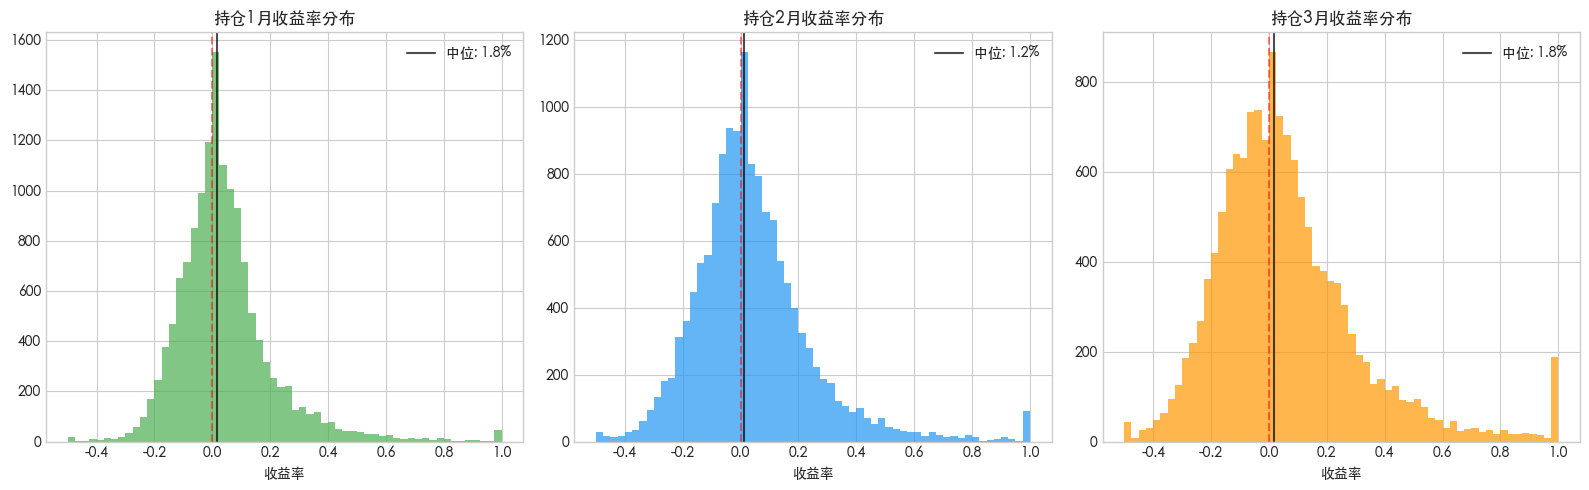

In [21]:
# 收益率分布对比
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, m in enumerate([1, 2, 3]):
    col = f'持仓{m}月收益率'
    v = detail[col].dropna()
    v_clip = v.clip(-0.5, 1.0)
    axes[i].hist(v_clip, bins=60, alpha=0.7, color=['#4CAF50', '#2196F3', '#FF9800'][i])
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.5)
    axes[i].axvline(v.median(), color='black', linestyle='-', alpha=0.7, label=f'中位: {v.median():.1%}')
    axes[i].set_title(f'持仓{m}月收益率分布')
    axes[i].set_xlabel('收益率')
    axes[i].legend()
plt.tight_layout()
plt.show()

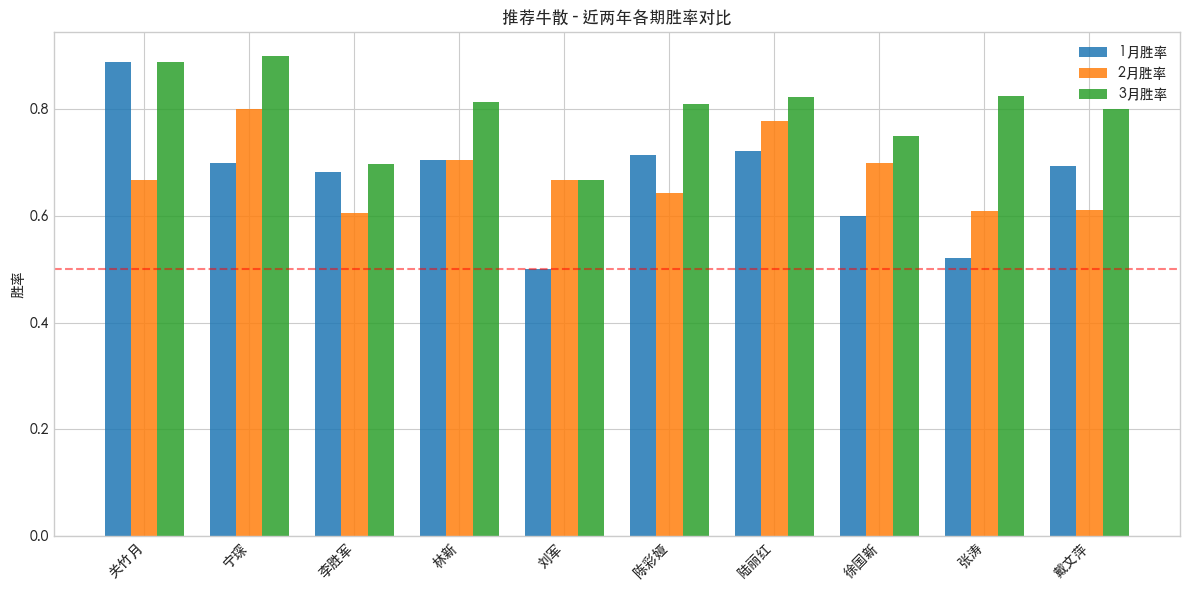

In [22]:
# 推荐牛散对比
if not recommended.empty:
    top10 = recommended.head(10)
    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(len(top10))
    w = 0.25
    for i, m in enumerate([1, 2, 3]):
        col = f'近2年_跟单{m}月_胜率'
        if col in top10.columns:
            vals = top10[col].fillna(0)
            ax.bar(x + i * w, vals, w, label=f'{m}月胜率', alpha=0.85)

    ax.set_xticks(x + w)
    ax.set_xticklabels(top10['牛散'], rotation=45, ha='right')
    ax.set_ylabel('胜率')
    ax.set_title('推荐牛散 - 近两年各期胜率对比')
    ax.legend()
    ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50%基准')
    plt.tight_layout()
    plt.show()

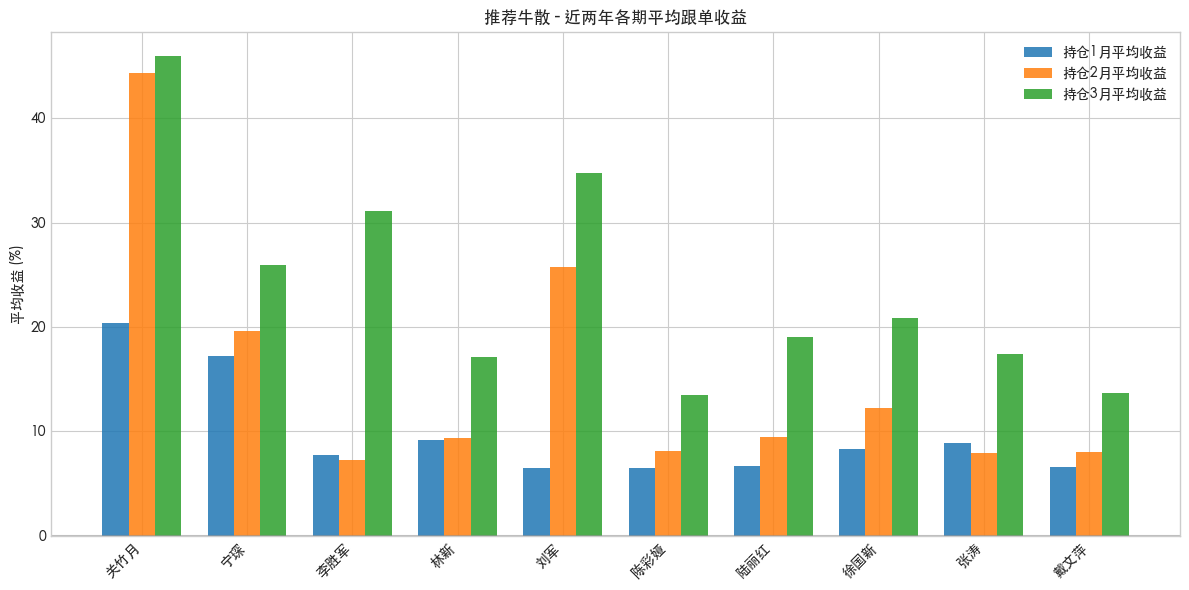

In [23]:
# 推荐牛散近两年各期平均跟单收益
if not recommended.empty:
    top10 = recommended.head(10)
    x = np.arange(len(top10))
    w = 0.25
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, m in enumerate([1, 2, 3]):
        col = f'近2年_跟单{m}月_平均收益'
        if col in top10.columns:
            vals = (top10[col].fillna(0) * 100)
            ax.bar(x + i * w, vals, w, label=f'持仓{m}月平均收益', alpha=0.85)
    ax.set_xticks(x + w)
    ax.set_xticklabels(top10['牛散'], rotation=45, ha='right')
    ax.set_ylabel('平均收益 (%)')
    ax.set_title('推荐牛散 - 近两年各期平均跟单收益')
    ax.legend()
    ax.axhline(0, color='gray', linestyle='-', alpha=0.5)
    plt.tight_layout()
    plt.show()